# Train Nordic OSM LoRA

Trains a multi-class LoRA adapter for `stable-diffusion-v1-5/stable-diffusion-inpainting`
on Norwegian / North European Sentinel-2 satellite imagery paired with OpenStreetMap
land-cover labels (boreal forest, fjords, alpine terrain, Nordic urban areas, etc.).

**Before running:** prepare the dataset first:
```bash
cd notebooks
uv run python prepare/prepare_osm_sentinel.py --output-dir ../datasets/osm_nordic
```

Key differences from `train_trees_lora.ipynb`:
- Each record carries its own per-class prompt (no single `INSTANCE_PROMPT`)
- Cosine LR schedule + 3000 steps (larger, 9-class dataset)
- Mask-weighted loss (emphasises repaint region, small background weight for context)
- No random crop (COG patches are already 512×512); horizontal flip augmentation only
- Per-class validation grid at each checkpoint

In [ ]:
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if all((candidate / d).exists() for d in ("backend", "frontend", "notebooks")):
            return candidate
    raise RuntimeError("Could not find repo root. Run this notebook from the repo or notebooks directory.")


REPO_ROOT = find_repo_root()
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
DATASET_DIR = REPO_ROOT / "datasets" / "osm_nordic"
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "lora_osm_nordic"
PREPARE_SCRIPT = REPO_ROOT / "notebooks" / "prepare" / "prepare_osm_sentinel.py"

# Fallback prompt used only if a record is missing its prompt field
DEFAULT_PROMPT = "satellite view, Scandinavian landscape, high resolution"
NEGATIVE_PROMPT = (
    "blurry, distorted, low quality, tropical, desert, "
    "warped perspective, repeated artifacts, watermark"
)

RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-4
MAX_TRAIN_STEPS = 3000
CHECKPOINTING_STEPS = 500
RANK = 16
LORA_ALPHA = 16
MASK_LOSS_WEIGHT = 1.0
BACKGROUND_LOSS_WEIGHT = 0.1
SEED = 42
LOCAL_FILES_ONLY = True
MIXED_PRECISION = "fp16"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", REPO_ROOT)
print("dataset:", DATASET_DIR)
print("output:", OUTPUT_DIR)

repo root: /data/pesch7299/source/inf3600-project
dataset: /data/pesch7299/source/inf3600-project/datasets/osm_nordic
output: /data/pesch7299/source/inf3600-project/notebooks/outputs/lora_osm_nordic


In [ ]:
import json
import math
import random
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration, set_seed
from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionInpaintPipeline, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params
from diffusers.utils import convert_state_dict_to_diffusers
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from transformers import CLIPTextModel, CLIPTokenizer


@dataclass
class Record:
    image_path: Path
    mask_path: Path
    prompt: str
    land_cover_class: str = ""


def load_records(dataset_dir: Path, default_prompt: str) -> list[Record]:
    metadata_path = dataset_dir / "metadata.jsonl"
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Missing dataset metadata: {metadata_path}\n"
            "Prepare the dataset first with:\n"
            f"  cd {REPO_ROOT / 'notebooks'}\n"
            f"  uv run python prepare/{PREPARE_SCRIPT.name} --output-dir ../datasets/{dataset_dir.name}"
        )
    records = []
    for line in metadata_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        row = json.loads(line)
        records.append(Record(
            image_path=dataset_dir / row["image"],
            mask_path=dataset_dir / row["mask"],
            prompt=row.get("prompt", default_prompt),
            land_cover_class=row.get("land_cover_class", ""),
        ))
    if not records:
        raise ValueError(f"No records found in {metadata_path}")
    return records


class InpaintDataset(Dataset):
    """Dataset for OSM Nordic LoRA training.

    Images arrive from geo.read_patch already at RESOLUTION×RESOLUTION, so
    we skip resizing and cropping and only apply horizontal flip augmentation.
    """

    def __init__(self, dataset_dir: Path, tokenizer, resolution: int, default_prompt: str):
        self.records = load_records(dataset_dir, default_prompt)
        self.tokenizer = tokenizer
        self.resolution = resolution
        self.image_to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self) -> int:
        return len(self.records)

    def preprocess(self, image: Image.Image, mask: Image.Image):
        # Ensure correct size (no-op for COG patches, guard against edge cases)
        if image.size != (self.resolution, self.resolution):
            image = image.resize((self.resolution, self.resolution), Image.Resampling.BILINEAR)
            mask = mask.resize((self.resolution, self.resolution), Image.Resampling.NEAREST)
        # Random horizontal flip — satellite imagery is rotation-invariant
        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        mask = mask.point(lambda v: 255 if v > 127 else 0)
        return image, mask

    def __getitem__(self, index: int) -> dict:
        record = self.records[index]
        image = Image.open(record.image_path).convert("RGB")
        mask = Image.open(record.mask_path).convert("L")
        image, mask = self.preprocess(image, mask)

        image_tensor = self.image_to_tensor(image)
        mask_tensor = (transforms.ToTensor()(mask) > 0.5).float()
        masked_image = image_tensor * (mask_tensor < 0.5)
        input_ids = self.tokenizer(
            record.prompt,
            padding="do_not_pad",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
        ).input_ids
        return {
            "pixel_values": image_tensor,
            "mask": mask_tensor,
            "masked_image": masked_image,
            "input_ids": input_ids,
        }


def collate_fn(examples: list[dict], tokenizer) -> dict:
    return {
        "pixel_values": torch.stack([e["pixel_values"] for e in examples]).contiguous().float(),
        "masks": torch.stack([e["mask"] for e in examples]).contiguous().float(),
        "masked_images": torch.stack([e["masked_image"] for e in examples]).contiguous().float(),
        "input_ids": tokenizer.pad(
            {"input_ids": [e["input_ids"] for e in examples]},
            padding=True,
            return_tensors="pt",
        ).input_ids,
    }


def save_lora(unet, output_dir: Path) -> None:
    state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    StableDiffusionInpaintPipeline.save_lora_weights(
        str(output_dir), unet_lora_layers=state_dict, safe_serialization=True
    )


records = load_records(DATASET_DIR, DEFAULT_PROMPT)
print(f"records: {len(records)}")

import collections
class_counts = collections.Counter(r.land_cover_class for r in records)
print("per-class counts:")
for cls, n in sorted(class_counts.items()):
    print(f"  {cls}: {n}")

records: 1200
per-class counts:
  airport: 150
  alpine: 150
  boreal_forest: 150
  farmland: 150
  grassland: 150
  industrial: 150
  nordic_urban: 150
  water: 150


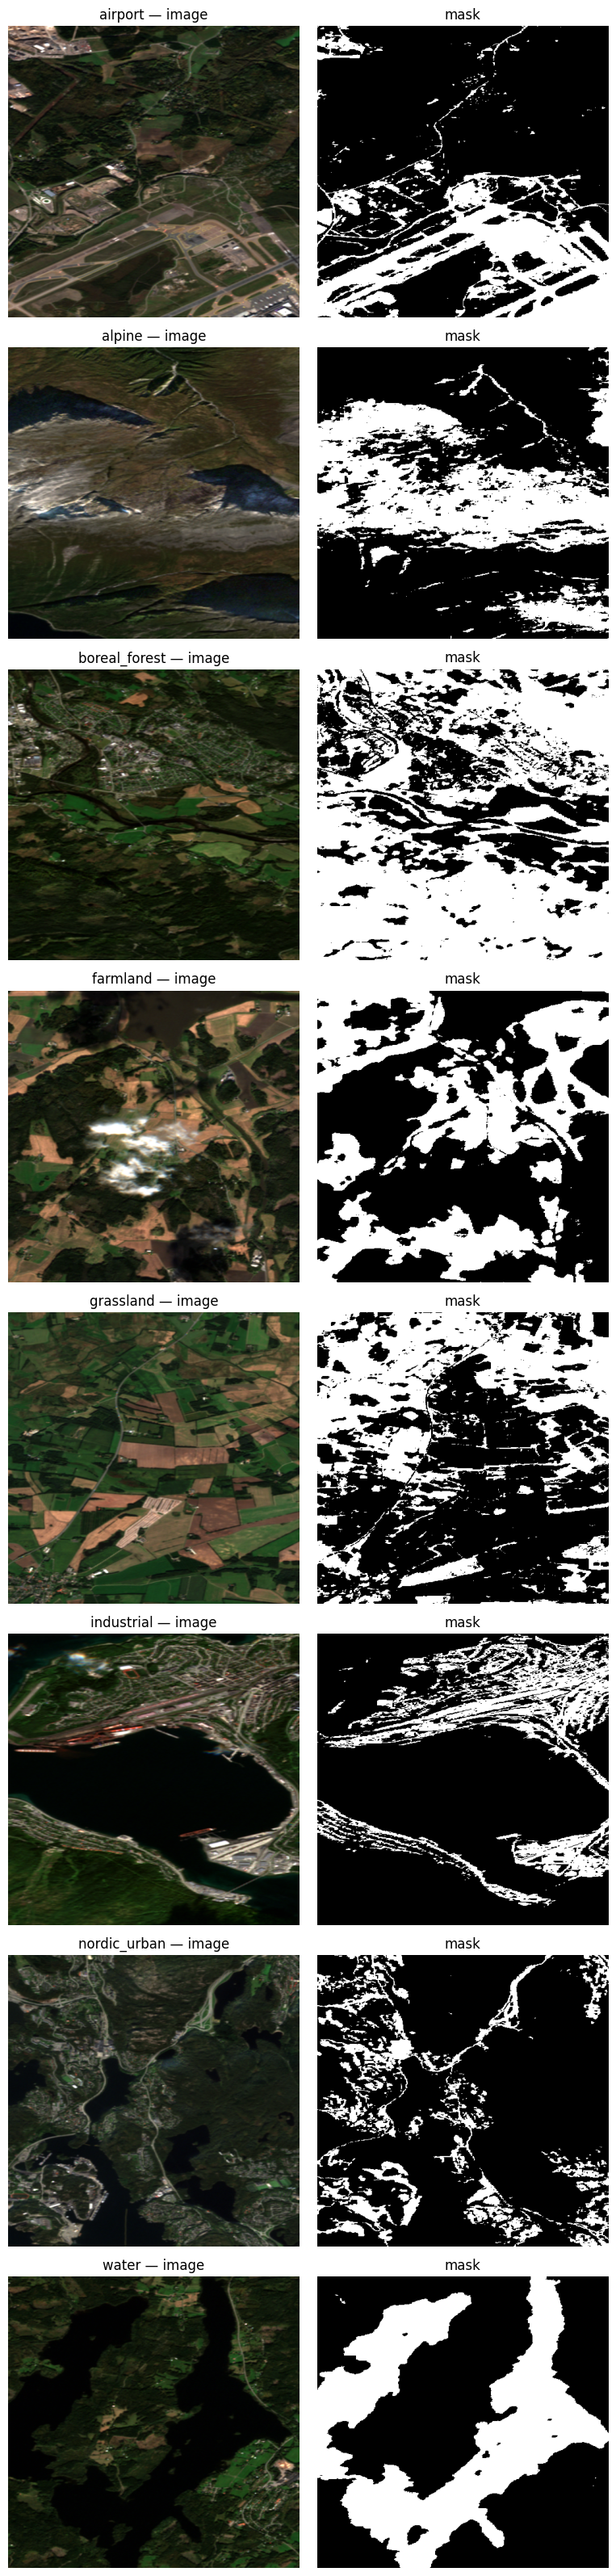

In [ ]:
# Per-class sample grid: one image + mask pair per land-cover class
by_class: dict[str, list[Record]] = collections.defaultdict(list)
for r in records:
    by_class[r.land_cover_class].append(r)

sample_classes = sorted(by_class.keys())
n_classes = len(sample_classes)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, 4 * n_classes))
if n_classes == 1:
    axes = [axes]
for row_axes, cls in zip(axes, sample_classes):
    rec = by_class[cls][0]
    img = Image.open(rec.image_path).convert("RGB")
    msk = Image.open(rec.mask_path).convert("L")
    row_axes[0].imshow(img)
    row_axes[0].set_title(f"{cls} — image")
    row_axes[0].axis("off")
    row_axes[1].imshow(msk, cmap="gray")
    row_axes[1].set_title("mask")
    row_axes[1].axis("off")
plt.tight_layout()

In [ ]:
set_seed(SEED)

accelerator = Accelerator(
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    mixed_precision=MIXED_PRECISION,
    project_config=ProjectConfiguration(
        project_dir=str(OUTPUT_DIR),
        logging_dir=str(OUTPUT_DIR / "logs"),
    ),
)

load_kwargs = {"local_files_only": LOCAL_FILES_ONLY}
model_load_kwargs = {**load_kwargs, "use_safetensors": False}

tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", **load_kwargs)
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", **model_load_kwargs)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", **model_load_kwargs)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", **model_load_kwargs)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler", **load_kwargs)

if int(unet.config.in_channels) != 9:
    raise RuntimeError(f"Expected inpainting UNet with 9 input channels, got {unet.config.in_channels}")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)
unet.add_adapter(LoraConfig(
    r=RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
))
unet.enable_gradient_checkpointing()
cast_training_params(unet, dtype=torch.float32)

weight_dtype = torch.float16 if MIXED_PRECISION == "fp16" else torch.float32
vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

dataset = InpaintDataset(DATASET_DIR, tokenizer, RESOLUTION, DEFAULT_PROMPT)
dataloader = DataLoader(
    dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda examples: collate_fn(examples, tokenizer),
)

trainable_params = [p for p in unet.parameters() if p.requires_grad]
print(f"trainable params: {sum(p.numel() for p in trainable_params):,}")

optimizer = torch.optim.AdamW(
    trainable_params, lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8
)
lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=MAX_TRAIN_STEPS,
)

unet, optimizer, dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, dataloader, lr_scheduler
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/data/pesch7299/source/inf3600-project/notebooks/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 3,188,736


In [ ]:
import time


def _plot_loss_curve(step_losses: list[dict], save_path: Path) -> None:
    steps = [e["step"] for e in step_losses]
    losses = [e["loss"] for e in step_losses]
    window = max(1, len(losses) // 50)
    smoothed = [
        sum(losses[max(0, i - window): i + 1]) / len(losses[max(0, i - window): i + 1])
        for i in range(len(losses))
    ]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, losses, alpha=0.25, color="steelblue", linewidth=0.8, label="step loss")
    ax.plot(steps, smoothed, color="steelblue", linewidth=2.0, label=f"smoothed (window={window})")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Masked MSE loss")
    ax.set_title("OSM Nordic LoRA — training loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=120)
    plt.close(fig)
    print(f"loss curve → {save_path}")


global_step = 0
steps_per_epoch = math.ceil(len(dataloader) / GRADIENT_ACCUMULATION_STEPS)
num_epochs = math.ceil(MAX_TRAIN_STEPS / max(1, steps_per_epoch))
step_losses: list[dict] = []
t_start = time.time()

print(f"Training: {MAX_TRAIN_STEPS} steps | {num_epochs} epochs | ~{steps_per_epoch} steps/epoch")
print(f"Checkpointing every {CHECKPOINTING_STEPS} steps\n")

for epoch in range(num_epochs):
    unet.train()
    epoch_loss_sum = 0.0
    epoch_steps = 0

    for step, batch in enumerate(dataloader):
        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(dtype=weight_dtype)
            masks = batch["masks"].to(dtype=weight_dtype)
            masked_images = batch["masked_images"].to(dtype=weight_dtype)
            input_ids = batch["input_ids"].to(accelerator.device)

            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
            masked_latents = vae.encode(masked_images).latent_dist.sample() * vae.config.scaling_factor
            mask_latents = F.interpolate(masks, size=latents.shape[-2:])

            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=latents.device,
            ).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            encoder_hidden_states = text_encoder(input_ids, return_dict=False)[0]
            model_input = torch.cat([noisy_latents, mask_latents, masked_latents], dim=1)
            model_pred = unet(
                model_input, timesteps, encoder_hidden_states=encoder_hidden_states, return_dict=False
            )[0]

            # Mask-weighted loss: emphasise repaint region, retain small background signal
            mask_weight = masks * MASK_LOSS_WEIGHT + (1.0 - masks) * BACKGROUND_LOSS_WEIGHT
            mask_weight_latent = F.interpolate(mask_weight, size=latents.shape[-2:])
            per_element_loss = F.mse_loss(model_pred.float(), noise.float(), reduction="none")
            loss = (per_element_loss * mask_weight_latent).mean()

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        if accelerator.sync_gradients:
            global_step += 1
            step_loss = loss.detach().item()
            lr_now = lr_scheduler.get_last_lr()[0]
            elapsed = time.time() - t_start
            sps = global_step / elapsed if elapsed > 0 else 0
            eta = (MAX_TRAIN_STEPS - global_step) / sps if sps > 0 else 0

            epoch_loss_sum += step_loss
            epoch_steps += 1

            step_losses.append({
                "step": global_step,
                "epoch": epoch + 1,
                "loss": round(step_loss, 6),
                "lr": round(lr_now, 8),
                "elapsed_s": round(elapsed, 1),
            })

            accelerator.print(
                f"[{global_step:4d}/{MAX_TRAIN_STEPS}] ep {epoch+1:2d}  "
                f"loss={step_loss:.4f}  lr={lr_now:.2e}  "
                f"elapsed={elapsed/60:.1f}min  eta={eta/60:.1f}min"
            )

            if global_step % CHECKPOINTING_STEPS == 0 and accelerator.is_main_process:
                ckpt_dir = OUTPUT_DIR / f"checkpoint-{global_step}"
                save_lora(accelerator.unwrap_model(unet), ckpt_dir)
                (OUTPUT_DIR / "loss_history.json").write_text(
                    json.dumps(step_losses, indent=2), encoding="utf-8"
                )
                _plot_loss_curve(step_losses, OUTPUT_DIR / f"loss_curve_step{global_step}.png")
                accelerator.print(f"checkpoint saved → {ckpt_dir}")

            if global_step >= MAX_TRAIN_STEPS:
                break

    if epoch_steps > 0:
        accelerator.print(
            f"\n── Epoch {epoch+1}/{num_epochs} │ "
            f"mean_loss={epoch_loss_sum/epoch_steps:.4f} │ "
            f"global_step={global_step}/{MAX_TRAIN_STEPS} ──\n"
        )

    if global_step >= MAX_TRAIN_STEPS:
        break

accelerator.wait_for_everyone()
if accelerator.is_main_process:
    save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR)
    (OUTPUT_DIR / "loss_history.json").write_text(
        json.dumps(step_losses, indent=2), encoding="utf-8"
    )
    _plot_loss_curve(step_losses, OUTPUT_DIR / "loss_curve_final.png")
    (OUTPUT_DIR / "training_args.json").write_text(
        json.dumps({
            "model_id": MODEL_ID,
            "dataset_dir": str(DATASET_DIR),
            "default_prompt": DEFAULT_PROMPT,
            "resolution": RESOLUTION,
            "max_train_steps": MAX_TRAIN_STEPS,
            "learning_rate": LEARNING_RATE,
            "lr_scheduler": "cosine",
            "rank": RANK,
            "lora_alpha": LORA_ALPHA,
            "mask_loss_weight": MASK_LOSS_WEIGHT,
            "background_loss_weight": BACKGROUND_LOSS_WEIGHT,
            "seed": SEED,
            "total_elapsed_min": round((time.time() - t_start) / 60, 1),
        }, indent=2),
        encoding="utf-8",
    )
print("saved:", OUTPUT_DIR / "pytorch_lora_weights.safetensors")

In [ ]:
# Per-class validation grid: one inpainted example per land-cover class
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID, torch_dtype=dtype, safety_checker=None,
    local_files_only=LOCAL_FILES_ONLY, use_safetensors=False,
).to(device)
pipe.load_lora_weights(str(OUTPUT_DIR), adapter_name="osm-nordic")
pipe.set_adapters(["osm-nordic"], adapter_weights=[1.0])
pipe.set_progress_bar_config(disable=True)

# Pick one validation record per class
val_records = [by_class[cls][0] for cls in sample_classes if cls in by_class]
n_val = len(val_records)

fig, axes = plt.subplots(n_val, 3, figsize=(15, 5 * n_val))
if n_val == 1:
    axes = [axes]

generator = torch.Generator(device=device).manual_seed(7)

for row_axes, rec in zip(axes, val_records):
    img = Image.open(rec.image_path).convert("RGB").resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)
    msk = Image.open(rec.mask_path).convert("L").resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)
    msk = msk.point(lambda v: 255 if v > 127 else 0)

    result = pipe(
        prompt=rec.prompt,
        negative_prompt=NEGATIVE_PROMPT,
        image=img,
        mask_image=msk,
        height=RESOLUTION,
        width=RESOLUTION,
        strength=1.0,
        num_inference_steps=40,
        guidance_scale=6.5,
        generator=generator,
    ).images[0]

    for ax, title, item, cmap in [
        (row_axes[0], f"{rec.land_cover_class}\noriginal", img, None),
        (row_axes[1], "mask", msk, "gray"),
        (row_axes[2], "inpainted", result, None),
    ]:
        ax.imshow(item, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_grid.png", dpi=100)
print("saved:", OUTPUT_DIR / "validation_grid.png")

In [ ]:
# Export the trained adapter to the backend model registry
export_cmd = (
    f"cd {REPO_ROOT / 'notebooks'} && "
    "uv run python ../scripts/export_lora.py \\",
    "  --id osm-nordic \\",
    "  --label \"Nordic Landcover (Sentinel-2)\" \\",
    f"  --adapter {OUTPUT_DIR} \\",
    f"  --prompt \"{DEFAULT_PROMPT}\" \\",
    f"  --negative \"{NEGATIVE_PROMPT}\""
)
print("Run this command to register the adapter with the backend:\n")
print("\n".join(export_cmd))